# EDA — Dataset Trivia Crack

Exploración del dataset para predecir churn en D1: dado un usuario que instaló el juego hoy, va a jugar mañana?

El objetivo de este notebook es entender la estructura de los datos, detectar problemas de calidad y ver qué features tienen más señal antes de modelar.

---

In [5]:
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv('Dataset DS - 26.CSV')

In [4]:
df.head()

,user_id,install_time,platform,country_region,city,gender,min_age_range,max_age_range,event_1,event_2,event_3,event_4,event_5,target_churn_indicator
0,2ba6f357,2018-07-04 19:24:24,Android,Santa Cruz,Río Gallegos,male,13,17,1,2,0,1,1,0
1,3cb936c1,2018-06-30 13:41:29,Android,Corrientes,Corrientes,male,13,17,0,7,0,3,0,1
2,17d88bbc,2018-06-30 16:02:30,Android,Cordoba,Villa Carlos Paz,female,18,20,2,1,0,2,2,1
3,7baa10b6,2018-07-02 21:08:33,Android,Buenos Aires,Don Torcuato,female,13,17,5,6,0,2,5,0
4,120d379,2018-07-07 04:18:47,Android,Santiago del Estero,Santiago del Estero,female,13,17,8,12,0,2,3,0


In [10]:
print(df.shape)
print(df.dtypes)

(20000, 14)
user_id                   object
install_time              object
platform                  object
country_region            object
city                      object
gender                    object
min_age_range              int64
max_age_range              int64
event_1                    int64
event_2                    int64
event_3                    int64
event_4                    int64
event_5                    int64
target_churn_indicator     int64
dtype: object


20000 filas, 14 columnas. `install_time` viene como `object` — hay que parsearlo a datetime antes de extraer features temporales. El resto de los tipos tiene sentido.

In [14]:
print((df.isnull().sum() / len(df) * 100).round(2))

user_id                   0.00
install_time              0.00
platform                  0.00
country_region            2.40
city                      4.68
gender                    0.00
min_age_range             0.00
max_age_range             0.00
event_1                   0.00
event_2                   0.00
event_3                   0.00
event_4                   0.00
event_5                   0.00
target_churn_indicator    0.00
dtype: float64


In [ ]:
# Verificar si los nulos de city y country_region se solapan
nulos_region = df['country_region'].isnull()
nulos_city = df['city'].isnull()
print(f"Nulos solo en city: {(nulos_city & ~nulos_region).sum()}")
print(f"Nulos en ambos: {(nulos_city & nulos_region).sum()}")

Nulos solo en city (no en region): 456
Nulos en ambos: 479


Los nulos están concentrados en las variables geográficas — 479 usuarios sin ninguna geo y 456 con región pero sin ciudad. Probablemente vienen de distintos niveles de precisión del servicio de geolocalización. Para el modelo se puede imputar con `"unknown"`.

---
### Duplicados

In [32]:
print(df['user_id'].duplicated().sum())
print(df['user_id'].nunique())

1467
18533


In [21]:
#Ejemplo de duplicado
ejemplo = df[df['user_id'] == df[df['user_id'].duplicated()]['user_id'].iloc[0]]
ejemplo

,user_id,install_time,platform,country_region,city,gender,min_age_range,max_age_range,event_1,event_2,event_3,event_4,event_5,target_churn_indicator
172,444d4e8e,2018-07-05 01:41:21,Android,Buenos Aires,Moron,male,18,20,5,32,0,3,2,0
574,444d4e8e,2018-07-05 01:41:21,Android,Cordoba,Córdoba,male,18,20,15,3,0,6,7,0


In [27]:
dupes = df[df['user_id'].duplicated(keep=False)].sort_values('user_id')
dupes

,user_id,install_time,platform,country_region,city,gender,min_age_range,max_age_range,event_1,event_2,event_3,event_4,event_5,target_churn_indicator
15280,1006ac06,2018-07-05 23:03:47,Android,Chaco,Resistencia,male,18,20,10,22,0,9,2,0
15359,1006ac06,2018-07-05 23:03:47,Android,Cordoba,Córdoba,male,18,20,1,1,0,3,1,0
17119,103cff6e,2018-07-04 22:30:57,Android,Buenos Aires,Lomas del Mirador,male,18,20,0,0,0,1,1,1
8954,103cff6e,2018-07-04 22:30:57,Android,Buenos Aires F.D.,Buenos Aires,male,18,20,7,7,1,6,1,1
6580,104faf7b,2018-07-01 18:14:19,Android,Buenos Aires,Belen de Escobar,female,13,17,8,8,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11194,ffe7ab34,2018-07-03 22:48:16,Android,Cordoba,Córdoba,male,18,20,19,21,1,9,5,0
2398,fff3cd99,2018-07-03 16:31:41,Android,Jujuy,San Salvador de Jujuy,female,13,17,3,3,0,4,1,0
4329,fff3cd99,2018-07-03 16:31:41,Android,Salta,Salta,female,13,17,5,5,0,2,3,0
17926,fff55850,2018-07-01 23:31:05,Android,Buenos Aires,Merlo,female,18,20,11,11,0,1,5,0


In [ ]:
# Hay duplicados con distinto target? (el peor caso)
target_conflict = dupes.groupby('user_id')['target_churn_indicator'].nunique()
print("Duplicados con target distinto:", (target_conflict > 1).sum())

# Todos tienen el mismo install_time?
time_conflict = dupes.groupby('user_id')['install_time'].nunique()
print("Duplicados con install_time distinto:", (time_conflict > 1).sum())

Duplicados con target distinto: 0
Duplicados con install_time distinto: 0


Sin conflictos de target ni de timestamp — los duplicados son ruido del pipeline, no reinstalaciones ni registros distintos. Se deduplica quedándose con la primera ocurrencia.

---
### Target

In [30]:
df['target_churn_indicator'].value_counts(normalize=True).round(2) * 100

target_churn_indicator
1    54.0
0    46.0
Name: proportion, dtype: float64

### Distribución del target

**54% churn** (target=1) vs **46% retención** (target=0). El desbalance es moderado. No requiere técnicas como SMOTE, pero conviene tenerlo en cuenta al elegir la métrica de evaluación y considerar `class_weight='balanced'` en el modelo.

In [33]:
df = df.drop_duplicates(subset='user_id', keep='first').reset_index(drop=True)
print("Shape después de deduplicar:", df.shape)

Shape después de deduplicar: (18533, 14)


In [45]:
events = ['event_1', 'event_2', 'event_3', 'event_4', 'event_5']

ceros = (df[events] == 0).sum()
ceros_pct = (ceros / len(df) * 100).round(1)
pd.DataFrame({'ceros': ceros, '% ceros': ceros_pct})

,ceros,% ceros
event_1,1321,7.1
event_2,1468,7.9
event_3,13851,74.7
event_4,22,0.1
event_5,1146,6.2


In [35]:
df[events].describe().round(2)

,event_1,event_2,event_3,event_4,event_5
count,18533.00,18533.00,18533.00,18533.00,18533.00
mean,13.83,19.02,0.53,4.36,4.53
std,19.21,27.26,1.25,4.22,4.55
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,3.00,0.00,1.00,2.00
50%,6.00,9.00,0.00,3.00,3.00
75%,18.00,24.00,1.00,6.00,6.00
max,218.00,437.00,20.00,43.00,64.00


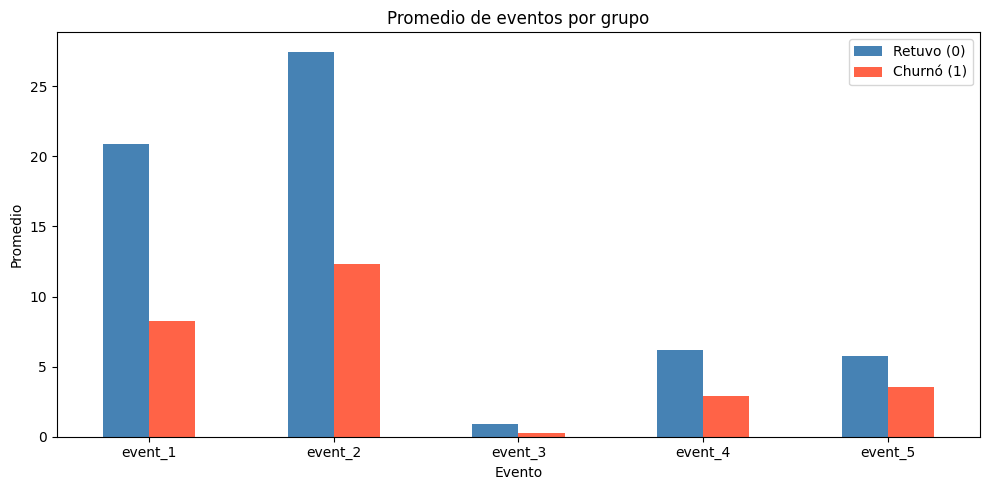

In [43]:
import matplotlib.pyplot as plt

means = df.groupby('target_churn_indicator')[events].mean().round(2)

means.T.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'tomato'])
plt.title('Promedio de eventos por grupo')
plt.xlabel('Evento')
plt.ylabel('Promedio')
plt.xticks(rotation=0)
plt.legend(['Retuvo (0)', 'Churnó (1)'])
plt.tight_layout()
plt.show()

In [44]:
df.groupby('target_churn_indicator')[events].mean().round(2)
df.groupby('target_churn_indicator')[events].mean().round(2)

,event_1,event_2,event_3,event_4,event_5
target_churn_indicator,,,,,
0,20.89,27.48,0.89,6.18,5.75
1,8.28,12.35,0.24,2.92,3.57


**Conclusiones de eventos:**

Los 5 eventos muestran la misma tendencia: los usuarios que retuvieron tienen promedios significativamente más altos que los que churnearon. Cuanto más jugó alguien en D0, más probable que vuelva al día siguiente.

- `event_1` y `event_2` son los más discriminativos (diferencia de ~2.5x entre grupos). Van a ser features clave en el modelo.
- `event_3` tiene un 74.7% de ceros (como numérico aporta poco). Conviene crear una feature binaria `event_3_used` (realizó o no el evento?).
- `event_4` es casi universal (0.1% de ceros), así que la señal está en la cantidad, no en si ocurrió.
- Todas las distribuciones son muy sesgadas a la derecha con outliers importantes puede valer la pena aplicar log transform antes de modelar.

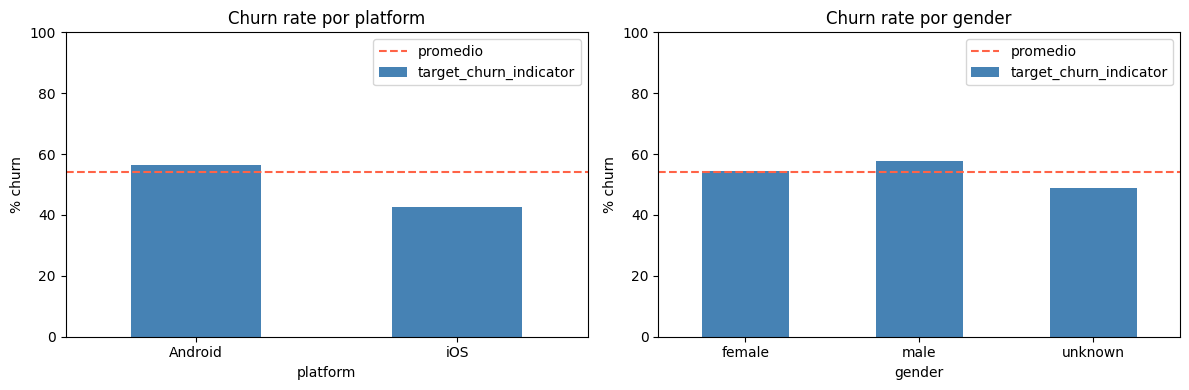

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['platform', 'gender']):
    churn_rate = df.groupby(col)['target_churn_indicator'].mean().round(3) * 100
    churn_rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Churn rate por {col}')
    ax.set_ylabel('% churn')
    ax.set_ylim(0, 100)
    ax.axhline(y=54, color='tomato', linestyle='--', label='promedio')
    ax.legend()
    ax.tick_params(axis='x', rotation=0)
    
plt.tight_layout()
plt.show()

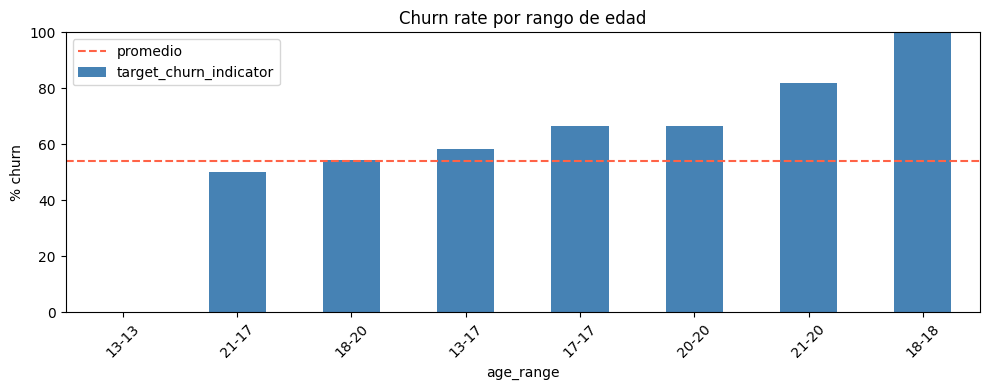

In [47]:
df['age_range'] = df['min_age_range'].astype(str) + '-' + df['max_age_range'].astype(str)

churn_age = df.groupby('age_range')['target_churn_indicator'].mean().round(3) * 100
churn_age.sort_values().plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.axhline(y=54, color='tomato', linestyle='--', label='promedio')
plt.title('Churn rate por rango de edad')
plt.ylabel('% churn')
plt.ylim(0, 100)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
print(df[['min_age_range', 'max_age_range']].value_counts().sort_index())
print("\nRangos inválidos (min > max):", (df['min_age_range'] > df['max_age_range']).sum())

min_age_range  max_age_range
13             13                   1
               17                6916
17             17                   3
18             18                   2
               20               11593
20             20                   3
21             17                   4
               20                  11
Name: count, dtype: int64

Rangos inválidos (min > max): 15


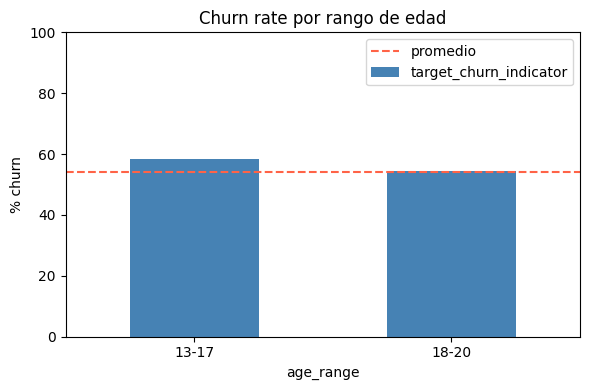

In [49]:
df_age = df[df['age_range'].isin(['13-17', '18-20'])]

churn_age = df_age.groupby('age_range')['target_churn_indicator'].mean().round(3) * 100
churn_age.plot(kind='bar', figsize=(6, 4), color='steelblue')
plt.axhline(y=54, color='tomato', linestyle='--', label='promedio')
plt.title('Churn rate por rango de edad')
plt.ylabel('% churn')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()  
plt.show()

**Conclusiones de features demográficas:**

- **Platform** es la más discriminativa del grupo: iOS tiene ~43% de churn vs ~57% en Android (14 puntos de diferencia). Tiene sentido que los usuarios de iOS tiendan a ser más engaged en juegos mobile.
- **Gender** muestra diferencias mínimas (female ~54%, male ~58%). Poca señal para el modelo.
- **Edad**: en la práctica hay dos grupos — `13-17` (~37%) y `18-20` (~63%). Los rangos puntuales e inválidos son ruido marginal (<30 registros). La diferencia de churn entre ambos grupos es pequeña (~5 puntos), así que la edad aporta poco por sí sola.

De las demográficas, solo `platform` vale la pena incluir con fuerza en el modelo.

---
## 4. Features temporales

In [51]:
df['install_time'] = pd.to_datetime(df['install_time'])

print("Rango de fechas:", df['install_time'].min(), "-", df['install_time'].max())
print("Días distintos:", df['install_time'].dt.date.nunique())

Rango de fechas: 2018-06-30 00:00:36 - 2018-07-07 23:59:47
Días distintos: 8


In [52]:
df['install_hour'] = df['install_time'].dt.hour
df['install_dow'] = df['install_time'].dt.dayofweek  # 0=lunes, 6=domingo
df['install_date'] = df['install_time'].dt.date

In [53]:
# Churn rate por hora del día
churn_hour = df.groupby('install_hour')['target_churn_indicator'].mean() * 100

# Churn rate por día de la semana
churn_dow = df.groupby('install_dow')['target_churn_indicator'].mean() * 100

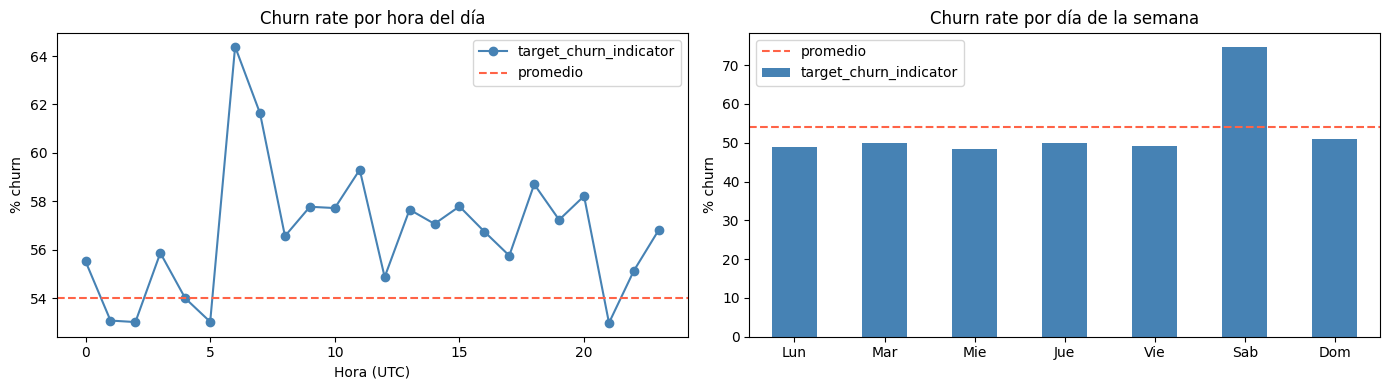

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

churn_hour.plot(ax=axes[0], color='steelblue', marker='o')
axes[0].axhline(y=54, color='tomato', linestyle='--', label='promedio')
axes[0].set_title('Churn rate por hora del día')
axes[0].set_xlabel('Hora (UTC)')
axes[0].set_ylabel('% churn')
axes[0].legend()

dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
churn_dow.index = dias
churn_dow.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(y=54, color='tomato', linestyle='--', label='promedio')
axes[1].set_title('Churn rate por día de la semana')
axes[1].set_ylabel('% churn')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
df.groupby('install_dow')['user_id'].count().reindex(range(7))

install_dow
0    2268
1    2396
2    2193
3    2138
4    2230
5    4689
6    2619
Name: user_id, dtype: int64

**Conclusiones de features temporales:**

- El dataset cubre 8 días (30 jun — 7 jul 2018), sin estacionalidad de largo plazo que preocupe.
- **Hora de instalación**: el pico de churn está entre las 5-6 UTC (2-3am en Argentina). Las horas de menor churn son la tarde-noche local. Tiene sentido: quien instala de madrugada tiene menos probabilidad de volver al día siguiente.
- **Día de la semana**: el sábado tiene ~73% de churn, muy por encima del promedio (54%), con 4.689 usuarios — suficiente muestra para que sea una señal real. El resto de los días está bastante parejo (~49-51%). Los usuarios que instalan el sábado churnan más; la causa exacta no es distinguible con estos datos.

`install_hour` e `install_dow` son features útiles para incluir en el modelo.

---
## Conclusiones generales del EDA

**Calidad de datos:**
- 7.3% de registros duplicados por un problema de geolocalización del pipeline. Se eliminan sin conflicto de target.
- Nulos solo en variables geográficas (2-5%), imputables con `"unknown"`.

**Features con más señal:**
- Los **eventos de D0** son las features más discriminativas. Los usuarios que retuvieron casi duplican o triplican en promedio a los que churnearon. `event_1` y `event_2` son los más fuertes.
- **Platform**: iOS churna 14 puntos menos que Android.
- **Hora y día de instalación** muestran patrones claros, especialmente el sábado y las horas de madrugada.

**Features con poca señal:**
- Género y edad tienen diferencias pequeñas entre grupos.
- Las variables geográficas (`country_region`, `city`) requieren encoding cuidadoso por su alta cardinalidad.

**Feature engineering sugerido antes de modelar:**
- `event_3_used`: binario (¿realizó o no el evento?)
- `is_weekend`: sábado/domingo vs resto
- Log transform en los eventos para reducir el efecto de outliers
- Imputar nulos geográficos con `"unknown"`